# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [2]:
! git clone https://github.com/lydialeelee/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 151 (delta 52), reused 22 (delta 22), pack-reused 82 (from 2)
Receiving objects: 100% (151/151), 13.99 MiB | 14.34 MiB/s, done.
Resolving deltas: 100% (63/63), done.


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Linear models assume the output is an unbounded, continuous value. In many cases, this doesn't happen to be true. For example, probabilities must lie in [0,1], and counts must be non-negative. GLMs apply an activation function to map a linear combination of inputs into a valid output range. We can model nonlinear relationships between features and outcomes while estimating interpretable linear coefficients on the pre-activation scale.
2. Cross-entropy is derived from maximum likelihood estimation under a Bernoulli (binary) or Categorical distribution. Minimizing cross-entropy is equivalent to maximizing the likelihood of the observed labels given the model's predicted probabilities. It penalizes confident wrong predictions heavily (e.g., predicting 0.99 when the label is 0), and it's a convex function in the model parameters, making optimization tractable.
3. True because the latent variable is a linear function of the features: b*x. But the predicted probability is a nonlinear transformation of that linear combination (via the sigmoid). So logistic regression is linear in the log-odds space but nonlinear in probability space.
4. False because logistic regression is normally used for classification. It outputs predicted probabilities, and you classify by thresholding.
5. Not directly because the coefficient b represents the change in the log-odds for a 1-unit increase in x. The change in the predicted probability depends on the current value of p-hat, so the effect on probability is not constant across observations.
6. False because while the sigmoid introduces nonlinearity in probability space, the decision boundary is still linear in feature space. Logistic regression cannot capture interactions or nonlinear feature relationships unless you explicitly engineer those features.
7. False because each model suits different situations. OLS is appropriate for continuous, unbounded outcomes. Logistic regression is appropriate for binary (or categorical) outcomes. Using logistic regression for a continuous outcome, or OLS for a probability, would be misspecified. The right model depends on your outcome type and assumptions.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [4]:
# 1.
df = pd.read_csv("/content/undergrad_ml_assignments/data/data.csv", sep=";")

cols = [
    "Debtor", "Tuition fees up to date", "Scholarship holder",
    "Age at enrollment", "Curricular units 1st sem (approved)", "Target"
]
df = df[cols].copy()

print(df.isnull().sum())   # inspect missing values
df = df.dropna()           # drop rows with any missing values (document choice)

# Binary target: 1 = Dropout, 0 = Graduate or Enrolled
df["dropout"] = (df["Target"] == "Dropout").astype(int)

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [5]:
# 2.
X2 = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y2 = df["dropout"]

lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X2, y2)

coef_df = pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": lr2.coef_[0]
})
print(coef_df)


                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


Variables that predict higher dropout probability are debtor (0.531) and age at enrollment (0.050). Variables that predict lower dropout probability are tuition fees up to date(-2.557) and scholarship holder (-1.227). Being up to date on tuition does reduce dropout risk because it has the largest coefficient in absolute value, meaning it has the strongest association with staying enrolled.

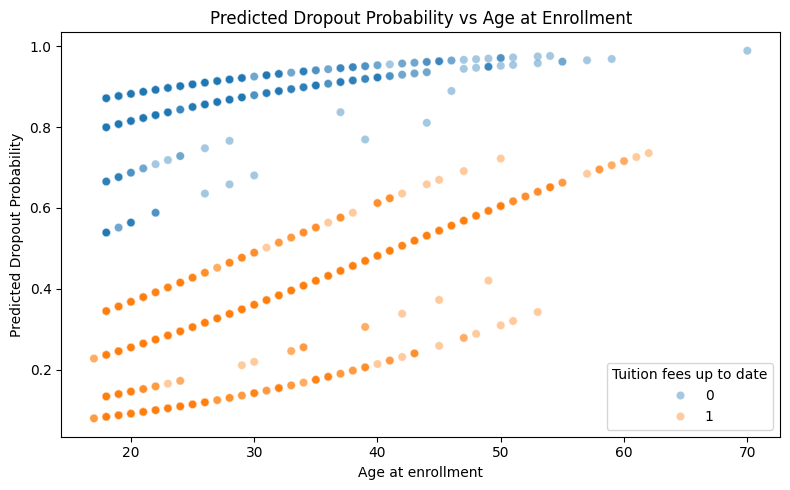

In [6]:
# 3
df["pred_prob"] = lr2.predict_proba(X2)[:, 1]

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df, x="Age at enrollment", y="pred_prob",
    hue="Tuition fees up to date", alpha=0.4, ax=ax
)
ax.set_ylabel("Predicted Dropout Probability")
ax.set_title("Predicted Dropout Probability vs Age at Enrollment")
plt.tight_layout()
plt.show()

The gap between the blue dots and orange dots is largest at younger ages, about 18-30. At those ages, the blue cluster sits around 0.55-0.90 while the orange cluster sits around 0.10-0.45.

The average difference is about 0.35-0.50, which means that students who are current on tuition have a predicted dropout probability that is roughly 35-45 percentage points lower on average than students who are not current.

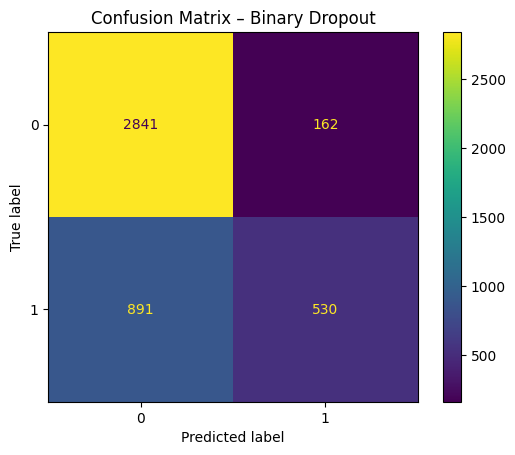

Accuracy: 0.762


In [7]:
# 4.
y_pred2 = lr2.predict(X2)
cm2 = confusion_matrix(y2, y_pred2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=lr2.classes_)
disp2.plot()
plt.title("Confusion Matrix – Binary Dropout")
plt.show()
print(f"Accuracy: {accuracy_score(y2, y_pred2):.3f}")

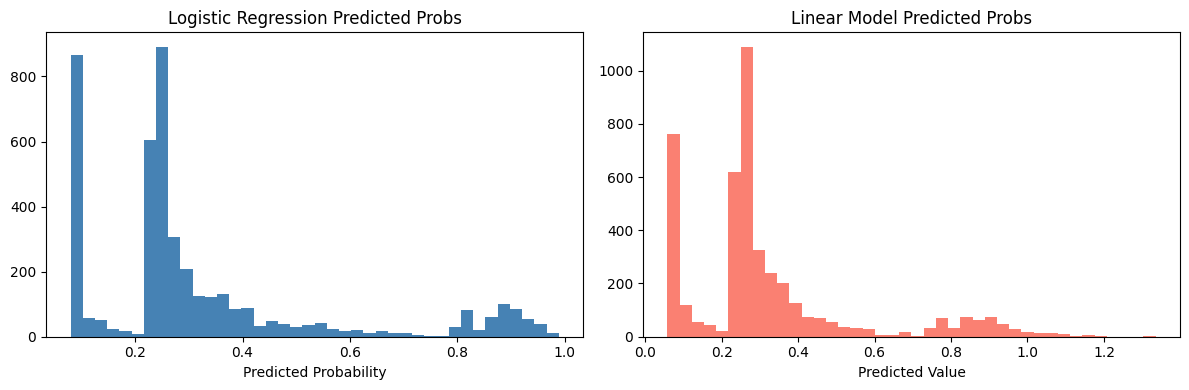

In [8]:
# 5.
ols2 = LinearRegression()
ols2.fit(X2, y2)
df["pred_prob_ols"] = ols2.predict(X2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].hist(df["pred_prob"],     bins=40, color="steelblue")
axes[0].set_title("Logistic Regression Predicted Probs")
axes[0].set_xlabel("Predicted Probability")
axes[1].hist(df["pred_prob_ols"], bins=40, color="salmon")
axes[1].set_title("Linear Model Predicted Probs")
axes[1].set_xlabel("Predicted Value")
plt.tight_layout()
plt.show()

6. Based on the logistic regression coefficient and the scatter plot, the highest-risk students are those who combine multiple risk factors like in debt, behind on tuition, no scholarship, and older at enrollment. Interventions that could help are financial interventions like small grants or expanded scholarship programs, academic interventions like mandatory check-ins, structural interventions like flexible payment plans and peer mentoring programs.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


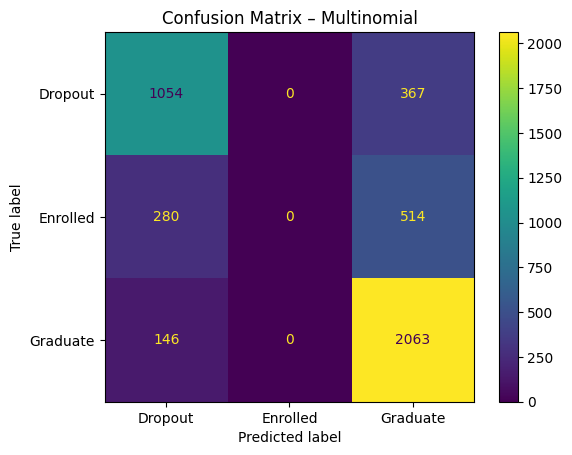

            Dropout     Enrolled     Graduate
count  4.424000e+03  4424.000000  4424.000000
mean   3.212229e-01     0.179474     0.499303
std    2.866920e-01     0.066308     0.287579
min    9.564711e-07     0.000279     0.002135
25%    1.178080e-01     0.140644     0.172735
50%    1.842268e-01     0.176983     0.603104
75%    5.898657e-01     0.212669     0.705209
max    9.601568e-01     0.327752     0.999720
Classes predicted (hard): ['Dropout' 'Graduate']


In [9]:
# 7.
X6 = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y6 = df["Target"]

mlr = LogisticRegression(multi_class="multinomial", max_iter=1000)
mlr.fit(X6, y6)

y_pred6 = mlr.predict(X6)
cm6 = confusion_matrix(y6, y_pred6, labels=mlr.classes_)
disp6 = ConfusionMatrixDisplay(cm6, display_labels=mlr.classes_)
disp6.plot()
plt.title("Confusion Matrix – Multinomial")
plt.show()

proba6 = pd.DataFrame(mlr.predict_proba(X6), columns=mlr.classes_)
print(proba6.describe())
print("Classes predicted (hard):", np.unique(y_pred6))


There are 1054 correctly classified as drop outs, 367 misclassified as graduates. Then, there are 280 enrolled that are misclassified as dropout and 514 enrolled misclassified as graduates. Then there are 146 graduates misclassified as dropouts and 2063 correctly classfied as graduates. This model does well on dropout and graduate, but completely fails on enrolled.

No, the hard classification doesn't predict every class because the entire middle column is 0. The model never predicts "Enrolled" for any student. It only makes a hard prediction of dropout and graduate.

Yes, the predicted probability assigns a nonzero probability to all three classes for every student. So even though the model never commits to predicting enrolled as the final label, it does assign it some probability internally.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [11]:
# 1.
df = pd.read_csv("/content/undergrad_ml_assignments/data/cirrhosis.csv")
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols].copy()

print(df.isnull().sum())
df = df.dropna()  # drop missing rows; document this choice

# Binary survival: 1 = alive (C or CL), 0 = dead (D)
df["alive"] = (df["Status"] != "D").astype(int)


Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?